In [1]:
import pandas as pd
import numpy as np
import sys
import os


In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.data_utils import (load_data)
from src.cleaning_utils import (drop_irrelevant_columns,
                                standardize_placeholders,
                                to_category,
                                handle_missing_values,
                                log_transform_skewed_columns,
                                cap_outliers_iqr,
                                drop_duplicates,
                                group_rare_categories,
                                convert_to_datetime,
                                save_cleaned_data
                                )



In [4]:


df_raw = load_data("C:/Users/ACER/Downloads/PumpHealth-main\data/df_clean.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ACER\AppData\Local\Temp\ipykernel_18984\2780876379.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_raw = load_data("C:/Users/ACER/Downloads/PumpHealth-main\data/df_clean.csv")


DataFrame successfully loaded.
Shape: (58857, 31)


In [5]:
cols_to_drop = [
    "id",                # unique identifier
    "wpt_name",          # too many unique values
    "recorded_by",        # constant value
    "scheme_name",       # too many unique values
    "num_private",     # too many zeros
    "extraction_type_group",  # already captured by extraction_type
    "payment_type",     # already captured by payment
    "quantity_group",   # already captured by quantity
    "waterpoint_type_group",  # already captured by waterpoint_type
    "subvillage"       # too many unique values
]

In [6]:
df_clean = drop_irrelevant_columns(df_raw, cols_to_drop)

Dropped columns: []


In [7]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
amount_tsh,58857.0,NaN,NaN,NaN,0.539388,0.838672,0.0,0.0,0.0,1.448822,2.213234
date_recorded,58857,356,2011-03-15,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funder,58857,20,Others,26808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gps_height,58857.0,NaN,NaN,NaN,674.462783,693.313778,-90.0,0.0,382.0,1323.0,2770.0
installer,58857,20,Others,24828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,58857.0,NaN,NaN,NaN,34.391279,5.721576,0.0,33.147223,34.937011,37.195204,40.345193
latitude,58857.0,NaN,NaN,NaN,-5.758645,2.907962,-11.64944,-8.57096,-5.063305,-3.338387,-0.0
basin,58857,9,Lake Victoria,9741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,58857,21,Iringa,5294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_code,58857.0,NaN,NaN,NaN,15.271998,17.666154,1.0,5.0,12.0,17.0,99.0


In [8]:
df_clean = standardize_placeholders(df_clean)

 Placeholder values replaced:
{'funder': 4416, 'installer': 4433, 'public_meeting': 3192, 'scheme_management': 3857, 'permit': 3056, 'management': 561, 'management_group': 561, 'payment': 7950, 'water_quality': 1800, 'quality_group': 1800, 'quantity': 789, 'source': 66, 'source_class': 277}


In [9]:
df_clean["funder"].head()

0    Others
1    Others
2    Others
3    Unicef
4    Others
Name: funder, dtype: object

In [10]:
df_clean = to_category(df_clean, cols=["district_code", "region_code"])

Converted to category: ['region_code', 'district_code']


In [11]:
print(df_clean[["region_code", "district_code"]].dtypes)

region_code      category
district_code    category
dtype: object


In [12]:
df_clean = convert_to_datetime(df_clean, cols=["date_recorded", "construction_year"])

Converted to datetime: ['date_recorded', 'construction_year']


In [13]:
print(df_clean[["date_recorded"]].dtypes)

date_recorded    datetime64[ns]
dtype: object


In [14]:
df_clean = drop_duplicates(df_clean)

Dropped 0 duplicate rows


In [15]:
df_clean.duplicated().any()

np.False_

In [16]:
df_clean = handle_missing_values(df_clean, strategy="fill", fill_value="Unknown")

Filled missing values (excluding: [])


In [17]:
df_clean.isna().sum()

amount_tsh               0
date_recorded            0
funder                   0
gps_height               0
installer                0
longitude                0
latitude                 0
basin                    0
region                   0
region_code              0
district_code            0
lga                      0
ward                     0
population               0
public_meeting           0
scheme_management        0
permit                   0
construction_year        0
extraction_type          0
extraction_type_class    0
management               0
management_group         0
payment                  0
water_quality            0
quality_group            0
quantity                 0
source                   0
source_type              0
source_class             0
waterpoint_type          0
status_group             0
dtype: int64

In [18]:
df_clean = group_rare_categories(df_clean, cols=[
    "extraction_type",
    "waterpoint_type",
    "installer",
    "funder",
    "scheme_management",
    "management",
    "water_quality",
    "quality_group",
    "quantity",
    "payment",
    "payment_type",
    "source",
    "source_type",
    "source_class"
], top_n=20, other_label="Others")

Grouped rare categories in: ['funder', 'installer', 'scheme_management', 'extraction_type', 'management', 'payment', 'water_quality', 'quality_group', 'quantity', 'source', 'source_type', 'source_class', 'waterpoint_type']


In [19]:
for col in [
    "extraction_type",
    "waterpoint_type",
    "installer",
    "funder"
]:
    print(f"{col}: {df_clean[col].nunique()} unique values")

extraction_type: 18 unique values
waterpoint_type: 7 unique values
installer: 20 unique values
funder: 20 unique values


In [20]:
df_clean = log_transform_skewed_columns(df_clean, cols=["amount_tsh", "population"], skew_threshold=1, inplace=False)

In [21]:
df_clean = cap_outliers_iqr(df_clean, cols=["amount_tsh", "population"], factor=1.5, inplace=False)

Outliers capped: amount_tsh
Outliers capped: population


In [22]:
save_cleaned_data(df_clean, "../data/df_clean.csv")

Saved cleaned data to: ../data/df_clean.csv


In [23]:
df_clean.shape

(58857, 31)

In [24]:
df_clean['date_recorded']

0       2011-03-14
1       2013-03-06
2       2013-02-25
3       2013-01-28
4       2011-07-13
           ...    
58852   2013-05-03
58853   2011-05-07
58854   2011-04-11
58855   2011-03-08
58856   2011-03-23
Name: date_recorded, Length: 58857, dtype: datetime64[ns]

In [25]:
df_clean['date_recorded'] = pd.to_datetime(df_clean['date_recorded'])
df_clean['date_recorded'].dt.year.value_counts()

date_recorded
2011    28454
2013    24065
2012     6307
2004       30
2002        1
Name: count, dtype: int64

In [26]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58857 entries, 0 to 58856
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   amount_tsh             58857 non-null  float64       
 1   date_recorded          58857 non-null  datetime64[ns]
 2   funder                 58857 non-null  object        
 3   gps_height             58857 non-null  int64         
 4   installer              58857 non-null  object        
 5   longitude              58857 non-null  float64       
 6   latitude               58857 non-null  float64       
 7   basin                  58857 non-null  object        
 8   region                 58857 non-null  object        
 9   region_code            58857 non-null  category      
 10  district_code          58857 non-null  category      
 11  lga                    58857 non-null  object        
 12  ward                   58857 non-null  object        
 13  p

In [27]:
df_clean['district_code']

0         5
1         2
2         4
3        63
4         1
         ..
58852     5
58853     4
58854     7
58855     4
58856     2
Name: district_code, Length: 58857, dtype: category
Categories (20, int64): [0, 1, 2, 3, ..., 62, 63, 67, 80]

In [28]:
df_clean["amount_tsh"] = pd.to_numeric(df_clean["amount_tsh"], errors="coerce").round().astype("Int64")
df_clean["longitude"] = pd.to_numeric(df_clean["longitude"], errors="coerce").round().astype("Int64")
df_clean["latitude"] = pd.to_numeric(df_clean["latitude"], errors="coerce").round().astype("Int64")
df_clean["population"] = pd.to_numeric(df_clean["population"], errors="coerce").round().astype("Int64")

In [29]:
# Status_group column has values "functional","non functional" and "functional needs repair"
df_clean['status_group'] = df_clean['status_group'].map({'functional': 0, 'non functional': 1, 'functional needs repair': 2})

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# Define the list of columns to drop
columns_to_drop = ['status_group', 'amount_tsh', 'region_code']

# Filter the list to include only columns that exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]

# Drop the existing columns

X =  df_clean.drop(existing_columns_to_drop, axis=1)
y = df_clean['status_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
len(X_train), len(X_test)

(47085, 11772)

In [33]:
categorical_features = X_train.select_dtypes(include=['object', 'int64']).columns
numerical_features = X_train.select_dtypes(include=['float64']).columns

In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
     ])

In [35]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index([], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['funder', 'gps_height', 'installer', 'longitude', 'latitude', 'basin',
       'region', 'lga', 'ward', 'population', 'public_meeting',
       'scheme_management', 'permit', 'extraction_type',
       'extraction_type_class', 'management', 'management_group', 'payment',
       'water_quality', 'quality_group', 'quantity', 'source', 'source_type',
       'source_class', 'waterpoint_type'],
      dtype='object'))])

In [36]:
from imblearn.over_sampling import SMOTE

from collections import Counter
import seaborn as sns

In [37]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [38]:
from imblearn.over_sampling import SMOTE

from collections import Counter
import seaborn as sns

Class distribution before handling imbalance: Counter({0: 25558, 1: 18124, 2: 3403})


<Axes: xlabel='status_group', ylabel='count'>

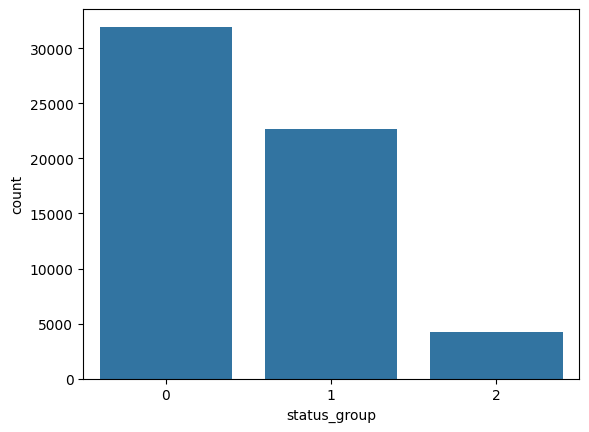

In [39]:
print("Class distribution before handling imbalance:", Counter(y_train))
sns.countplot(x ='status_group' , data = df_clean)

Class distribution after SMOTE: Counter({0: 25558, 1: 25558, 2: 25558})


<Axes: xlabel='status_group', ylabel='count'>

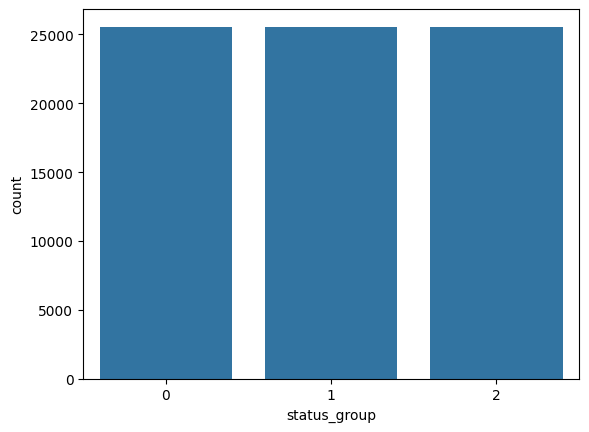

In [40]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(preprocessor.fit_transform(X_train), y_train)

print("Class distribution after SMOTE:", Counter(y_train_resampled))
sns.countplot(x ='status_group' , data = pd.DataFrame(y_train_resampled, columns=['status_group']))

In [41]:
from sklearn.ensemble import RandomForestClassifier


In [42]:
X_train_processed = preprocessor.fit_transform(X_train)

# Fit model
rf_model = RandomForestClassifier(random_state=42, n_estimators=10)
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [43]:
train_preds = rf_model.predict(preprocessor.transform(X_train))
train_preds

array([0, 1, 0, ..., 0, 1, 1], shape=(47085,))

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
train_acc = accuracy_score(y_train, train_preds)
print(train_acc)

0.9499203568015292


In [46]:
test_preds = rf_model.predict(preprocessor.transform(X_test))

In [47]:
test_acc = accuracy_score(y_test, test_preds)
print(test_acc)

0.7850832483860006
